<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/example%20RC%20LSM%20Spiking%20Neural%20Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Input shape: torch.Size([1, 1, 500])


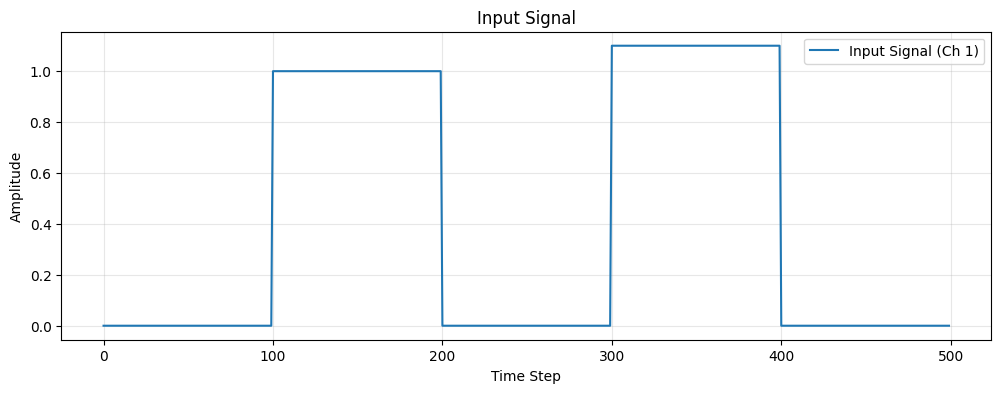

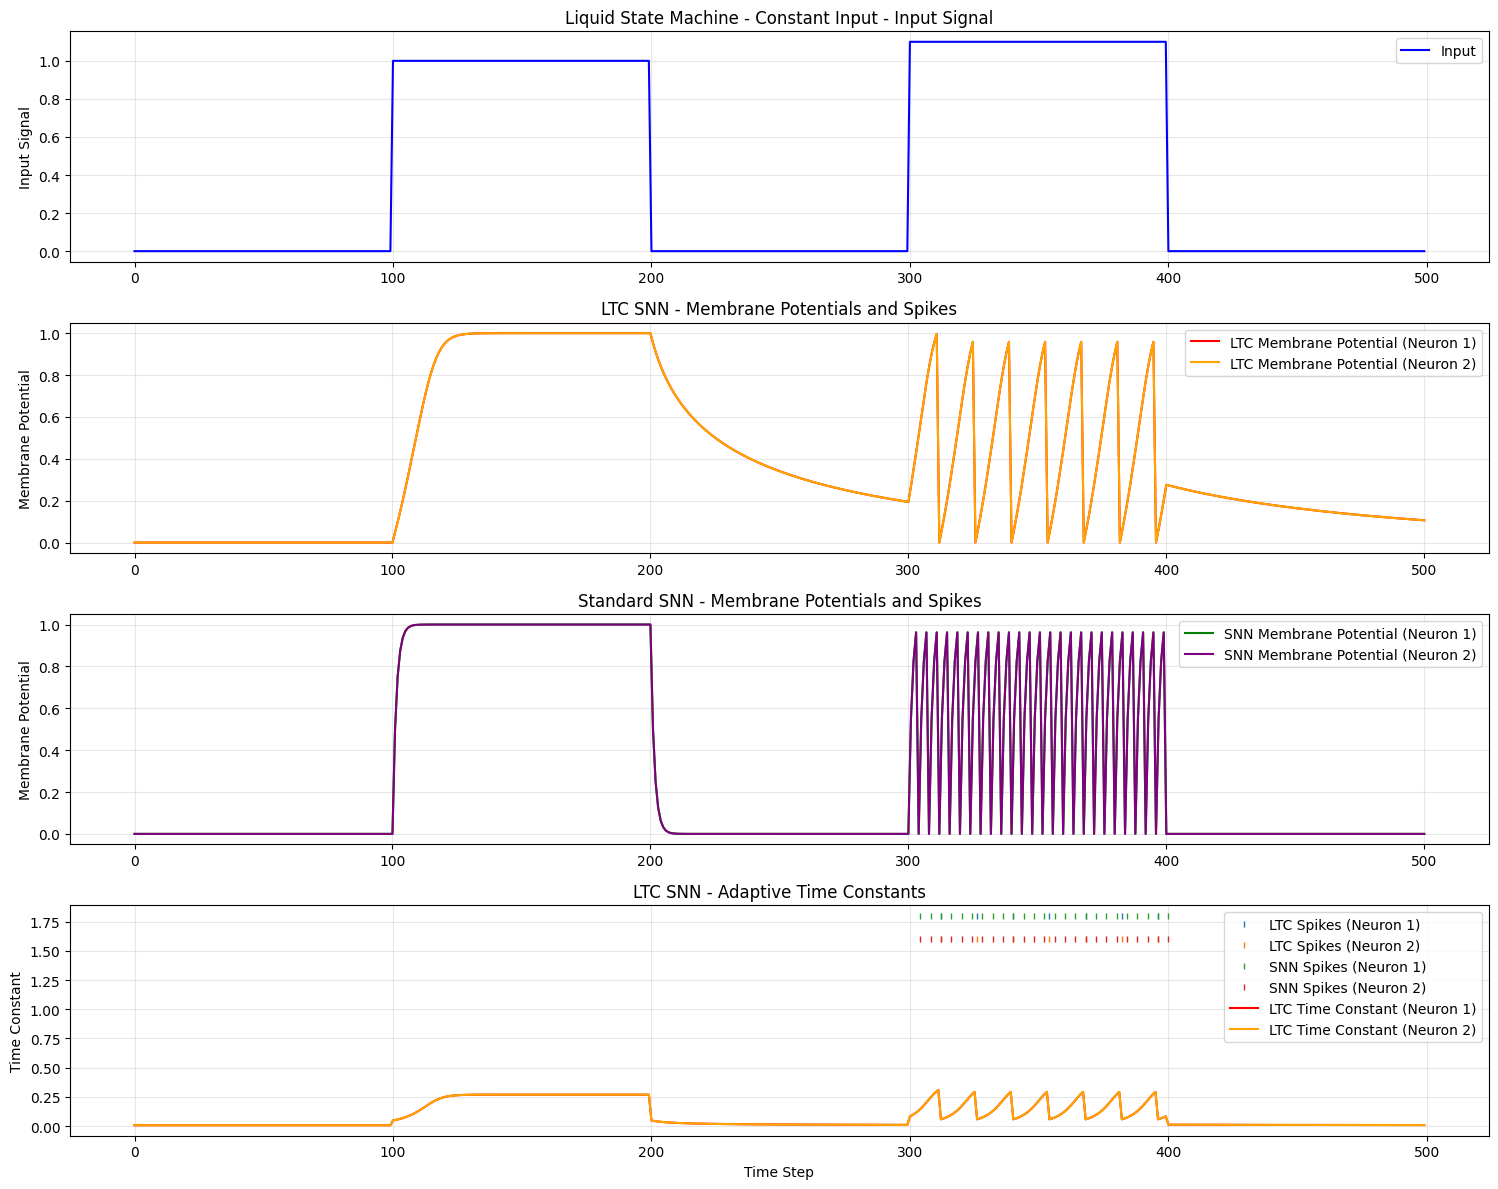

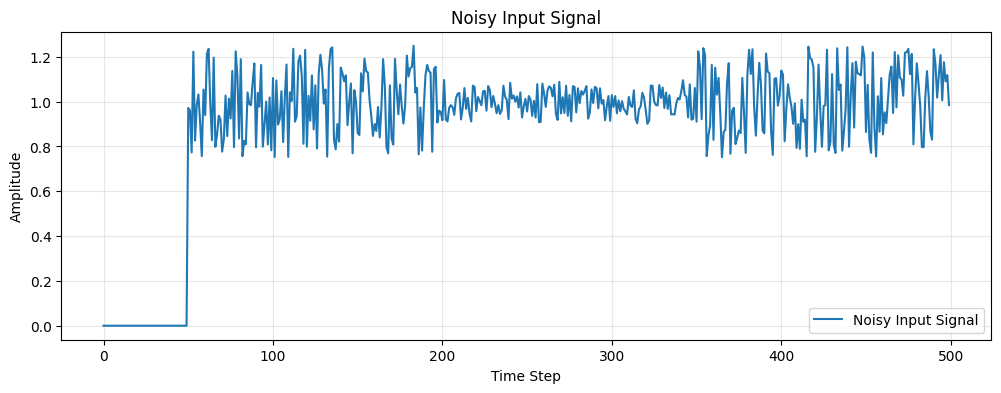

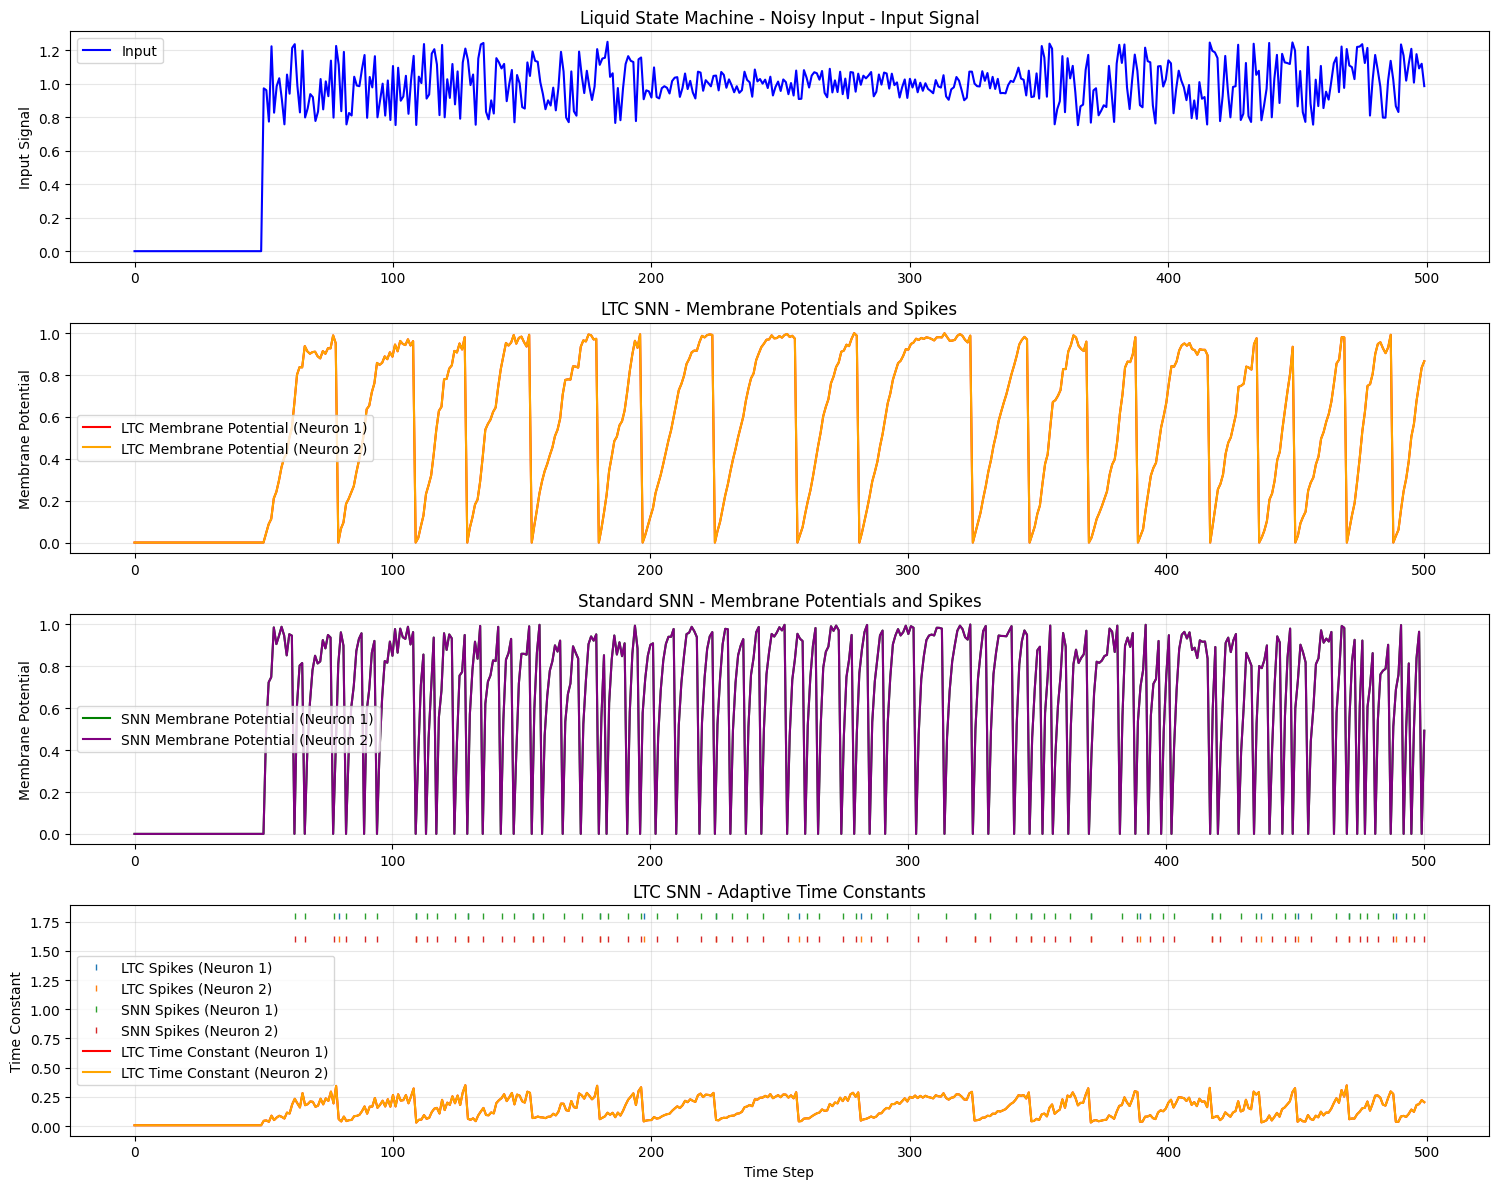

Computing F-I curves...


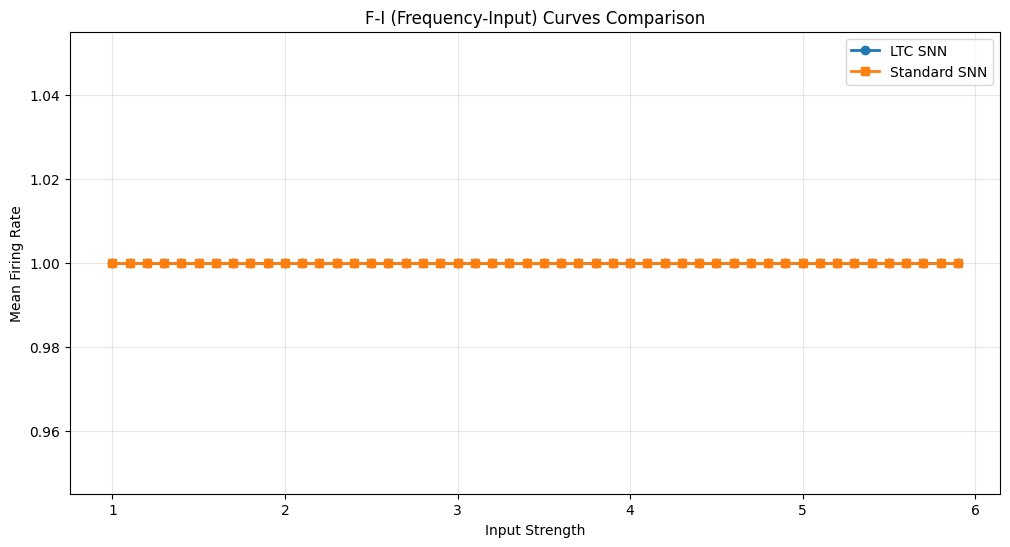

/tmp/ipython-input-2122653854.py:372: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


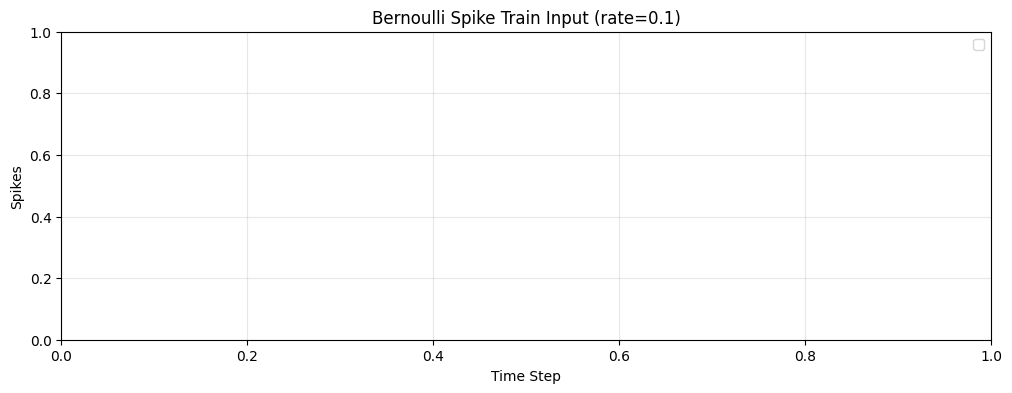

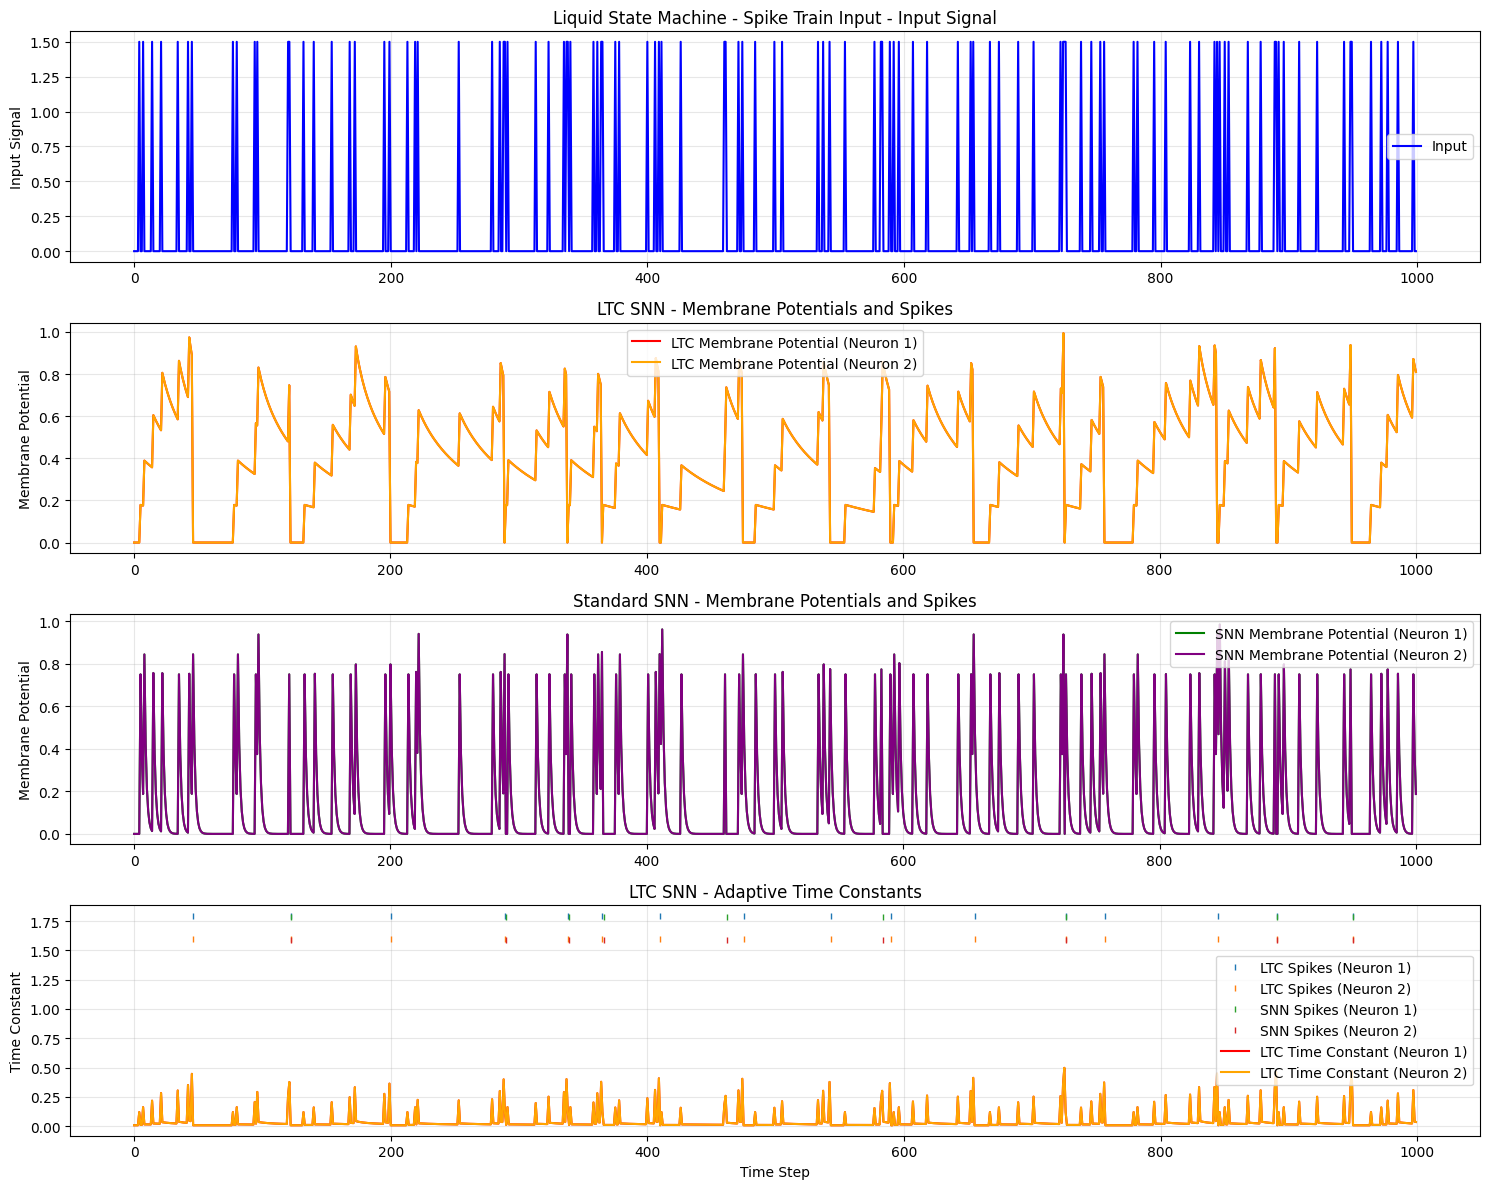

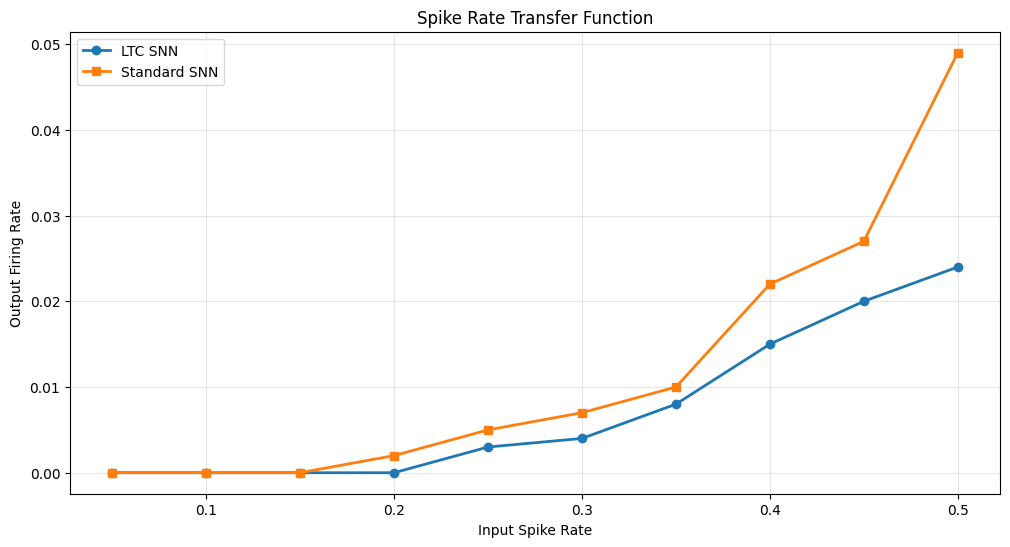

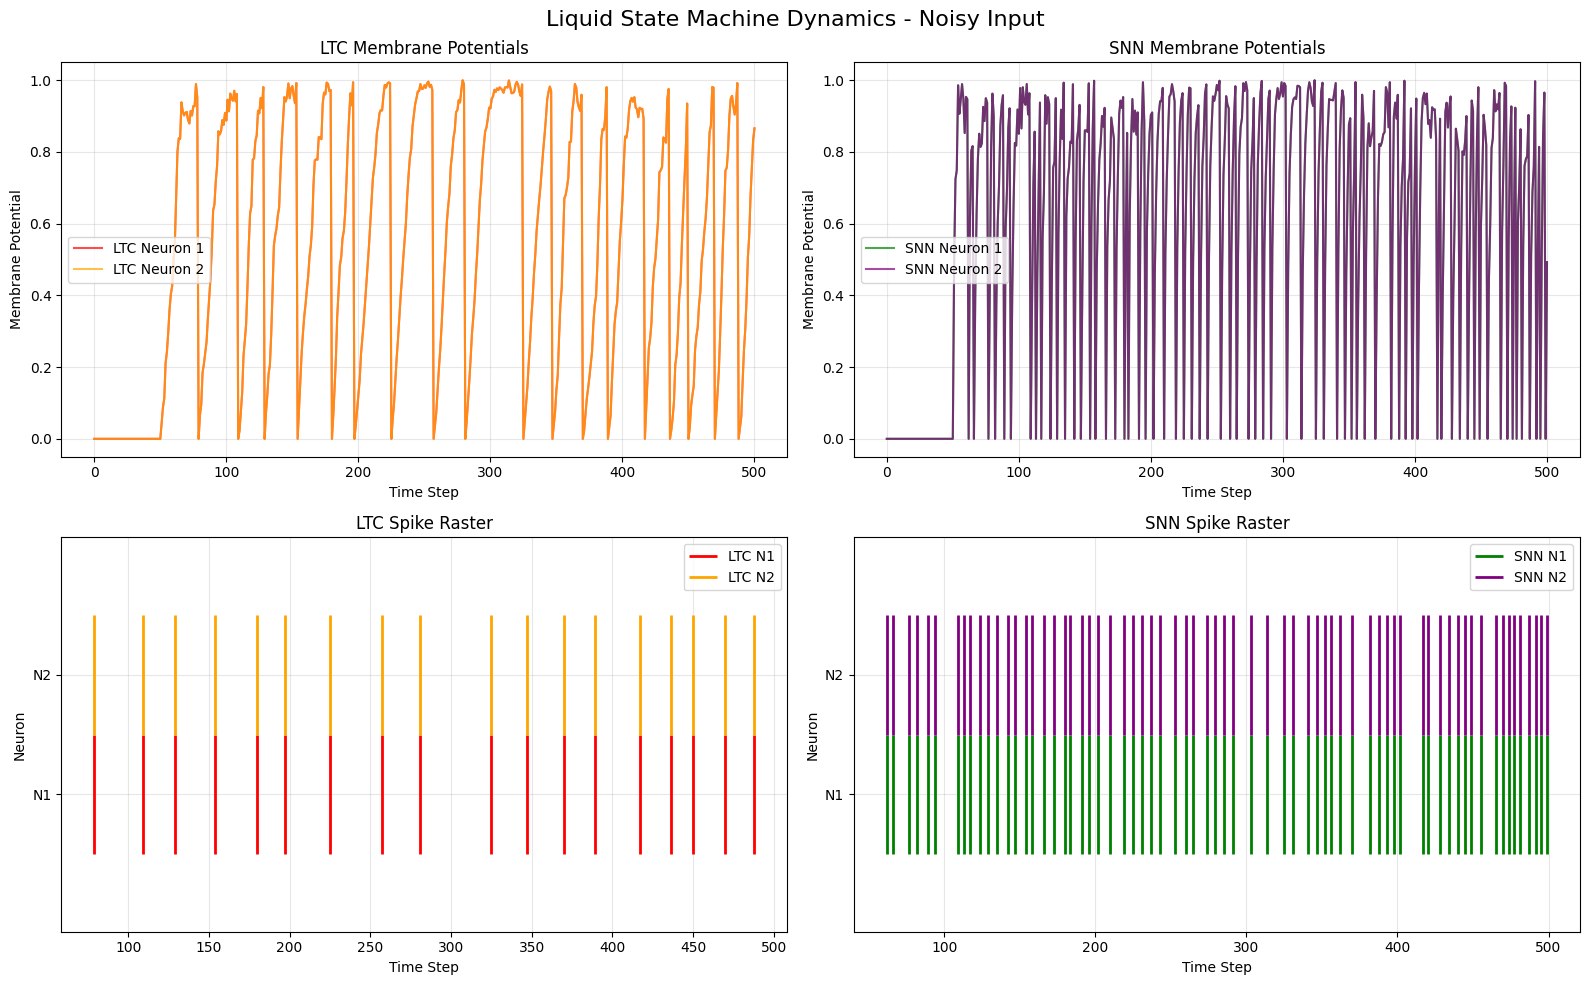


=== Network Comparison Summary ===
LTC Network - Mean firing rate (noisy input): 0.0359
SNN Network - Mean firing rate (noisy input): 0.1357
LTC Network - Mean membrane potential (noisy input): 0.5438
SNN Network - Mean membrane potential (noisy input): 0.6159

LTC Network - Mean firing rate (spike train): 0.0160
SNN Network - Mean firing rate (spike train): 0.0090


In [ ]:

# # Spiking Neural Network Analysis and Visualization
#
# This notebook analyzes two types of spiking neural network cells: a basic SNN cell and an LTC (Liquid Time-Constant) SNN cell. We'll visualize their behavior similar to a Liquid State Machine.

# %%
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
from torch.nn import init
from torch.autograd import Variable
import math

# %%
gamma = .5  # gradient scale
lens = 0.3

def gaussian(x, mu=0., sigma=.5):
    return torch.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) / torch.sqrt(2 * torch.tensor(math.pi)) / sigma


class ActFun_adp(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):  # input = membrane potential- threshold
        ctx.save_for_backward(input)
        return input.gt(0).float()  # is firing ???

    @staticmethod
    def backward(ctx, grad_output):  # approximate the gradients
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # temp = abs(input) < lens
        scale = 6.0
        hight = .15
        # temp = torch.exp(-(input**2)/(2*lens**2))/torch.sqrt(2*torch.tensor(math.pi))/lens
        temp = gaussian(input, mu=0., sigma=lens) * (1. + hight) \
               - gaussian(input, mu=lens, sigma=scale * lens) * hight \
               - gaussian(input, mu=-lens, sigma=scale * lens) * hight
        # temp =  gaussian(input, mu=0., sigma=lens)
        return grad_input * temp.float() * gamma
        # return grad_input


act_fun_adp = ActFun_adp.apply

def mem_update_adp(inputs, mem, spike, tau_adp, tau_m, b, dt=1, isAdapt=1):
    alpha = tau_m

    # ro = tau_adp

    # if isAdapt:
    #     beta = 1.8
    # else:
    #     beta = 0.

    # b = ro * b + (1 - ro) * spike
    # B = b_j0 + beta * b
    B = 1.

    d_mem = -mem + inputs
    mem = mem + d_mem * alpha
    inputs_ = mem - B

    spike = act_fun_adp(inputs_)  # act_fun : approximation firing function
    mem = (1-spike)*mem

    return mem, spike, B, b

# %%
class LTC_SNN_rec_cell(nn.Module):
    def __init__(self, input_size, hidden_size, is_rec=False):
        super(LTC_SNN_rec_cell, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.is_rec = is_rec

        if is_rec:
            self.layer1_x = nn.Linear(input_size+hidden_size, hidden_size)
        else:
            self.layer1_x = nn.Linear(input_size, hidden_size)
        self.layer1_tauAdp = nn.Linear(hidden_size, hidden_size)
        self.layer1_tauM = nn.Linear(hidden_size, hidden_size)

        self.act1 = nn.Sigmoid()

        nn.init.ones_(self.layer1_x.weight)
        nn.init.ones_(self.layer1_tauAdp.weight)
        nn.init.ones_(self.layer1_tauM.weight)

        nn.init.zeros_(self.layer1_x.bias)
        nn.init.constant_(self.layer1_tauAdp.bias, -5.)
        nn.init.constant_(self.layer1_tauM.bias, -5.)

    def forward(self, x_t, mem_t, spk_t, b_t):
        if self.is_rec:
            dense_x = self.layer1_x(torch.cat((x_t, spk_t), dim=-1))
        else:
            dense_x = self.layer1_x(x_t)
        tauM1 = self.act1(self.layer1_tauM(dense_x + mem_t))
        tauAdp1 = self.act1(self.layer1_tauAdp(dense_x + b_t))


        mem_1, spk_1, _, b_1 = mem_update_adp(dense_x, mem=mem_t, spike=spk_t,
                                              tau_adp=tauAdp1, tau_m=tauM1, b=b_t)

        return mem_1, spk_1, b_1, tauM1

    def compute_output_size(self):
        return [self.hidden_size]

class SNN_rec_cell(nn.Module):
    def __init__(self, input_size, hidden_size, is_rec=False):
        super(SNN_rec_cell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.is_rec = is_rec

        if is_rec:
            self.layer1_x = nn.Linear(input_size+hidden_size, hidden_size)
        else:
            self.layer1_x = nn.Linear(input_size, hidden_size)

        self.tau_adp = nn.Parameter(torch.Tensor(hidden_size))
        self.tau_m = nn.Parameter(torch.Tensor(hidden_size))
        self.act1 = nn.Sigmoid()

        nn.init.constant_(self.tau_adp, 4.6)
        nn.init.constant_(self.tau_m, 0.)
        nn.init.ones_(self.layer1_x.weight)
        nn.init.zeros_(self.layer1_x.bias)

    def forward(self, x_t, mem_t, spk_t, b_t):
        if self.is_rec:
            dense_x = self.layer1_x(torch.cat((x_t, spk_t), dim=-1))
        else:
            dense_x = self.layer1_x(x_t)
        tauM1 = self.act1(self.tau_m)
        tauAdp1 = self.act1(self.tau_adp)

        mem_1, spk_1, _, b_1 = mem_update_adp(dense_x, mem=mem_t, spike=spk_t,
                                              tau_adp=tauAdp1, tau_m=tauM1, b=b_t)

        return mem_1, spk_1, b_1

    def compute_output_size(self):
        return [self.hidden_size]

# %%
def plot_spk(spk_list, shape='*', label='spk', baseline=0.):
    """Plot spike times"""
    if isinstance(spk_list, torch.Tensor):
        spk_list = spk_list.detach().cpu().numpy()
    spk_t = np.where(spk_list == 1)[0]
    if len(spk_t) > 0:
        plt.plot(spk_t, np.ones(len(spk_t)) + baseline, shape, label=label, markersize=4)

def visualize_liquid_state_machine(ltc_snn, snn, x, T=500, title="Liquid State Machine Visualization"):
    """Visualize the behavior of SNNs like a Liquid State Machine"""

    # Initialize states
    mem_snn = torch.zeros(1, 2)
    spk_snn = torch.zeros(1, 2)
    b_snn = torch.zeros(1, 2)

    mem_ltc = torch.zeros(1, 2)
    spk_ltc = torch.zeros(1, 2)
    b_ltc = torch.zeros(1, 2)

    # Store time series
    mem_ltc_list = []
    spk_ltc_list = []
    tauM_ltc_list = []

    mem_snn_list = []
    spk_snn_list = []

    # Initial states
    mem_ltc_list.append(mem_ltc.detach().numpy())
    spk_ltc_list.append(spk_ltc.detach().numpy())
    mem_snn_list.append(mem_snn.detach().numpy())
    spk_snn_list.append(spk_snn.detach().numpy())

    # Simulate over time
    for i in range(T):
        mem_ltc, spk_ltc, b_ltc, tau_ltc = ltc_snn(x[:, :, i], mem_ltc, spk_ltc, b_ltc)
        mem_snn, spk_snn, b_snn = snn(x[:, :, i], mem_snn, spk_snn, b_snn)

        tauM_ltc_list.append(tau_ltc.detach().numpy())
        mem_ltc_list.append(mem_ltc.detach().numpy())
        spk_ltc_list.append(spk_ltc.detach().numpy())
        mem_snn_list.append(mem_snn.detach().numpy())
        spk_snn_list.append(spk_snn.detach().numpy())

    # Convert to numpy arrays
    mem_ltc_np = np.array(mem_ltc_list)
    spk_ltc_np = np.array(spk_ltc_list)
    tau_ltc_np = np.array(tauM_ltc_list)

    mem_snn_np = np.array(mem_snn_list)
    spk_snn_np = np.array(spk_snn_list)

    # Create visualization
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))

    time_steps = range(T+1)  # Include initial state

    # Plot 1: Input signal
    axes[0].plot(range(T), x[0, 0, :].cpu().numpy(), label='Input', color='blue', linewidth=1.5)
    axes[0].set_ylabel('Input Signal')
    axes[0].set_title(f'{title} - Input Signal')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Plot 2: LTC Membrane Potential
    axes[1].plot(time_steps, mem_ltc_np[:, 0, 0], label='LTC Membrane Potential (Neuron 1)', color='red', linewidth=1.5)
    axes[1].plot(time_steps, mem_ltc_np[:, 0, 1], label='LTC Membrane Potential (Neuron 2)', color='orange', linewidth=1.5)
    plot_spk(spk_ltc_np[:, 0, 0], shape='|', label='LTC Spikes (Neuron 1)', baseline=np.max(mem_ltc_np[:, 0, 0])*0.8)
    plot_spk(spk_ltc_np[:, 0, 1], shape='|', label='LTC Spikes (Neuron 2)', baseline=np.max(mem_ltc_np[:, 0, 1])*0.6)
    axes[1].set_ylabel('Membrane Potential')
    axes[1].set_title('LTC SNN - Membrane Potentials and Spikes')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Plot 3: SNN Membrane Potential
    axes[2].plot(time_steps, mem_snn_np[:, 0, 0], label='SNN Membrane Potential (Neuron 1)', color='green', linewidth=1.5)
    axes[2].plot(time_steps, mem_snn_np[:, 0, 1], label='SNN Membrane Potential (Neuron 2)', color='purple', linewidth=1.5)
    plot_spk(spk_snn_np[:, 0, 0], shape='|', label='SNN Spikes (Neuron 1)', baseline=np.max(mem_snn_np[:, 0, 0])*0.8)
    plot_spk(spk_snn_np[:, 0, 1], shape='|', label='SNN Spikes (Neuron 2)', baseline=np.max(mem_snn_np[:, 0, 1])*0.6)
    axes[2].set_ylabel('Membrane Potential')
    axes[2].set_title('Standard SNN - Membrane Potentials and Spikes')
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    # Plot 4: LTC Time Constants
    axes[3].plot(time_steps[:-1], tau_ltc_np[:, 0, 0], label='LTC Time Constant (Neuron 1)', color='red', linewidth=1.5)
    axes[3].plot(time_steps[:-1], tau_ltc_np[:, 0, 1], label='LTC Time Constant (Neuron 2)', color='orange', linewidth=1.5)
    axes[3].set_ylabel('Time Constant')
    axes[3].set_xlabel('Time Step')
    axes[3].set_title('LTC SNN - Adaptive Time Constants')
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    plt.tight_layout()
    plt.show()

    return {
        'mem_ltc': mem_ltc_np,
        'spk_ltc': spk_ltc_np,
        'tau_ltc': tau_ltc_np,
        'mem_snn': mem_snn_np,
        'spk_snn': spk_snn_np
    }

def compute_fi_curve(ltc_snn, snn, input_range, T=500):
    """Compute the F-I (Frequency-Input) curve for both networks"""
    mean_fr_ltc = []
    mean_fr_snn = []

    for s in input_range:
        x = torch.ones(T).view(1, 1, T) * s

        # Initialize states
        mem_snn_state = torch.zeros(1, 2)
        spk_snn_state = torch.zeros(1, 2)
        b_snn_state = torch.zeros(1, 2)

        mem_ltc_state = torch.zeros(1, 2)
        spk_ltc_state = torch.zeros(1, 2)
        b_ltc_state = torch.zeros(1, 2)

        spk_ltc_temp = []
        spk_snn_temp = []

        for i in range(T):
            mem_ltc_state, spk_ltc_state, b_ltc_state, _ = ltc_snn(x[:, :, i], mem_ltc_state, spk_ltc_state, b_ltc_state)
            mem_snn_state, spk_snn_state, b_snn_state = snn(x[:, :, i], mem_snn_state, spk_snn_state, b_snn_state)

            spk_ltc_temp.append(spk_ltc_state.detach().numpy())
            spk_snn_temp.append(spk_snn_state.detach().numpy())

        spk_ltc_np = np.array(spk_ltc_temp)
        spk_snn_np = np.array(spk_snn_temp)

        mean_fr_ltc.append(np.mean(spk_ltc_np))
        mean_fr_snn.append(np.mean(spk_snn_np))

    return input_range, mean_fr_ltc, mean_fr_snn

def plot_fi_curves(ltc_snn, snn, input_range=range(10, 60)):
    """Plot the F-I curves for both networks"""
    inputs, fr_ltc, fr_snn = compute_fi_curve(ltc_snn, snn, input_range)

    plt.figure(figsize=(12, 6))
    plt.plot([i/10.0 for i in inputs], fr_ltc, label='LTC SNN', marker='o', linewidth=2, markersize=6)
    plt.plot([i/10.0 for i in inputs], fr_snn, label='Standard SNN', marker='s', linewidth=2, markersize=6)
    plt.xlabel('Input Strength')
    plt.ylabel('Mean Firing Rate')
    plt.title('F-I (Frequency-Input) Curves Comparison')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# %%
# Create network instances
ltc_snn = LTC_SNN_rec_cell(1, 2)
snn = SNN_rec_cell(1, 2)

# %%
# Test with constant input
T = 500
x = torch.zeros(T).view(1, 1, T)
x[:, :, 100:200] = 1.0
x[:, :, 300:400] = 1.1

print("Input shape:", x.shape)
plt.figure(figsize=(12, 4))
plt.plot(x.detach().cpu().numpy()[0, 0, :], label='Input Signal (Ch 1)')
plt.title('Input Signal')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# %%
# Visualize the networks with constant input
results = visualize_liquid_state_machine(ltc_snn, snn, x, T=500,
                                         title="Liquid State Machine - Constant Input")

# %%
# Test with noisy input
T = 500
x_noisy = torch.zeros(T).view(1, 1, T)
x_noisy[:, :, 50:200] = 1.0 + 0.5 * (torch.rand(150) - 0.5)
x_noisy[:, :, 200:350] = 1.0 + 0.2 * (torch.rand(150) - 0.5)
x_noisy[:, :, 350:500] = 1.0 + 0.5 * (torch.rand(150) - 0.5)

plt.figure(figsize=(12, 4))
plt.plot(x_noisy.detach().cpu().numpy()[0, 0, :], label='Noisy Input Signal')
plt.title('Noisy Input Signal')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# %%
# Visualize with noisy input
results_noisy = visualize_liquid_state_machine(ltc_snn, snn, x_noisy, T=500,
                                               title="Liquid State Machine - Noisy Input")

# %%
# Plot F-I curves
print("Computing F-I curves...")
plot_fi_curves(ltc_snn, snn, input_range=range(10, 60))

# %%
# Test with Bernoulli (spike train) input
T = 1000
input_rate = 0.1
x_bernoulli = torch.bernoulli(torch.ones(T) * input_rate).view(1, 1, T) * 1.5

plt.figure(figsize=(12, 4))
plot_spk(x_bernoulli[0, 0, :].cpu().numpy(), shape='|', label='Spike Train Input')
plt.title('Bernoulli Spike Train Input (rate=0.1)')
plt.xlabel('Time Step')
plt.ylabel('Spikes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# %%
# Visualize with Bernoulli input
results_bernoulli = visualize_liquid_state_machine(ltc_snn, snn, x_bernoulli, T=1000,
                                                   title="Liquid State Machine - Spike Train Input")

# %%
# Compare firing rates across different input rates
input_rates = np.arange(0.05, 0.55, 0.05)
mean_fr_ltc_rates = []
mean_fr_snn_rates = []

for rate in input_rates:
    x_rate = torch.bernoulli(torch.ones(1000) * rate).view(1, 1, 1000) * 1.1

    # Initialize states
    mem_snn_state = torch.zeros(1, 2)
    spk_snn_state = torch.zeros(1, 2)
    b_snn_state = torch.zeros(1, 2)

    mem_ltc_state = torch.zeros(1, 2)
    spk_ltc_state = torch.zeros(1, 2)
    b_ltc_state = torch.zeros(1, 2)

    spk_ltc_temp = []
    spk_snn_temp = []

    for i in range(1000):
        mem_ltc_state, spk_ltc_state, b_ltc_state, _ = ltc_snn(x_rate[:, :, i], mem_ltc_state, spk_ltc_state, b_ltc_state)
        mem_snn_state, spk_snn_state, b_snn_state = snn(x_rate[:, :, i], mem_snn_state, spk_snn_state, b_snn_state)

        spk_ltc_temp.append(spk_ltc_state.detach().numpy())
        spk_snn_temp.append(spk_snn_state.detach().numpy())

    spk_ltc_np = np.array(spk_ltc_temp)
    spk_snn_np = np.array(spk_snn_temp)

    mean_fr_ltc_rates.append(np.mean(spk_ltc_np))
    mean_fr_snn_rates.append(np.mean(spk_snn_np))

# Plot firing rates vs input rates
plt.figure(figsize=(12, 6))
plt.plot(input_rates, mean_fr_ltc_rates, label='LTC SNN', marker='o', linewidth=2, markersize=6)
plt.plot(input_rates, mean_fr_snn_rates, label='Standard SNN', marker='s', linewidth=2, markersize=6)
plt.xlabel('Input Spike Rate')
plt.ylabel('Output Firing Rate')
plt.title('Spike Rate Transfer Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# %%
# Create a comprehensive visualization showing the liquid state dynamics
def plot_liquid_state_dynamics(results_dict, title="Liquid State Dynamics"):
    """Plot the liquid state dynamics with multiple visualization panels"""

    mem_ltc = results_dict['mem_ltc']
    spk_ltc = results_dict['spk_ltc']
    tau_ltc = results_dict['tau_ltc']
    mem_snn = results_dict['mem_snn']
    spk_snn = results_dict['spk_snn']

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    T = mem_ltc.shape[0] - 1  # Subtract 1 because we stored initial state

    # Panel 1: LTC membrane potentials over time
    time_steps = range(T+1)
    axes[0, 0].plot(time_steps, mem_ltc[:, 0, 0], label='LTC Neuron 1', color='red', alpha=0.7)
    axes[0, 0].plot(time_steps, mem_ltc[:, 0, 1], label='LTC Neuron 2', color='orange', alpha=0.7)
    axes[0, 0].set_title('LTC Membrane Potentials')
    axes[0, 0].set_xlabel('Time Step')
    axes[0, 0].set_ylabel('Membrane Potential')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Panel 2: SNN membrane potentials over time
    axes[0, 1].plot(time_steps, mem_snn[:, 0, 0], label='SNN Neuron 1', color='green', alpha=0.7)
    axes[0, 1].plot(time_steps, mem_snn[:, 0, 1], label='SNN Neuron 2', color='purple', alpha=0.7)
    axes[0, 1].set_title('SNN Membrane Potentials')
    axes[0, 1].set_xlabel('Time Step')
    axes[0, 1].set_ylabel('Membrane Potential')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Panel 3: Spike raster plots
    axes[1, 0].eventplot([np.where(spk_ltc[:, 0, 0] == 1)[0]], lineoffsets=1, colors='red', label='LTC N1', linewidths=2)
    axes[1, 0].eventplot([np.where(spk_ltc[:, 0, 1] == 1)[0]], lineoffsets=2, colors='orange', label='LTC N2', linewidths=2)
    axes[1, 0].set_title('LTC Spike Raster')
    axes[1, 0].set_xlabel('Time Step')
    axes[1, 0].set_ylabel('Neuron')
    axes[1, 0].set_yticks([1, 2])
    axes[1, 0].set_yticklabels(['N1', 'N2'])
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Panel 4: SNN spike raster
    axes[1, 1].eventplot([np.where(spk_snn[:, 0, 0] == 1)[0]], lineoffsets=1, colors='green', label='SNN N1', linewidths=2)
    axes[1, 1].eventplot([np.where(spk_snn[:, 0, 1] == 1)[0]], lineoffsets=2, colors='purple', label='SNN N2', linewidths=2)
    axes[1, 1].set_title('SNN Spike Raster')
    axes[1, 1].set_xlabel('Time Step')
    axes[1, 1].set_ylabel('Neuron')
    axes[1, 1].set_yticks([1, 2])
    axes[1, 1].set_yticklabels(['N1', 'N2'])
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize the dynamics from the noisy input experiment
plot_liquid_state_dynamics(results_noisy, "Liquid State Machine Dynamics - Noisy Input")

# %%
# Print summary statistics
print("\n=== Network Comparison Summary ===")
print(f"LTC Network - Mean firing rate (noisy input): {np.mean(results_noisy['spk_ltc']):.4f}")
print(f"SNN Network - Mean firing rate (noisy input): {np.mean(results_noisy['spk_snn']):.4f}")
print(f"LTC Network - Mean membrane potential (noisy input): {np.mean(results_noisy['mem_ltc']):.4f}")
print(f"SNN Network - Mean membrane potential (noisy input): {np.mean(results_noisy['mem_snn']):.4f}")

print(f"\nLTC Network - Mean firing rate (spike train): {np.mean(results_bernoulli['spk_ltc']):.4f}")
print(f"SNN Network - Mean firing rate (spike train): {np.mean(results_bernoulli['spk_snn']):.4f}")